In [12]:
import subprocess
import sys
from pathlib import Path
import importlib

cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

try:
    import matplotlib.pyplot as plt
    import pandas as pd
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(project_root / "requirements.txt")])
    import matplotlib.pyplot as plt
    import pandas as pd

# Forcer le rechargement du module common pour que la configuration soit à jour
if 'common' in sys.modules:
    del sys.modules['common']
import common
importlib.reload(common)

<module 'common' from 'C:\\Users\\bruna\\OneDrive\\Documents\\Aflokkat\\Master\\nyc_taxi_trip\\common.py'>

In [13]:
CSV_PATH = f"{common.CONFIG['paths']['raw_data']}/{common.CONFIG['dataset']['csv_file']}"

In [14]:
data = pd.read_csv(CSV_PATH)

In [15]:
print(data.shape)

(1458644, 11)


In [16]:
print(data.sample(10))

                id  vendor_id      pickup_datetime     dropoff_datetime  \
12422    id2550606          1  2016-03-31 10:23:32  2016-03-31 10:28:04   
1126195  id0063860          1  2016-01-09 01:03:30  2016-01-09 01:10:46   
1120101  id0609256          2  2016-06-22 20:53:06  2016-06-22 21:37:39   
84406    id2648307          1  2016-04-06 09:57:30  2016-04-06 10:11:49   
211036   id3205946          1  2016-06-02 23:51:00  2016-06-02 23:57:06   
912701   id3193700          2  2016-02-11 10:41:33  2016-02-11 10:56:00   
298038   id0913632          1  2016-05-16 02:02:57  2016-05-16 02:10:42   
172593   id2508782          2  2016-01-21 10:39:08  2016-01-21 10:47:30   
1291664  id0512559          2  2016-06-08 00:31:04  2016-06-08 00:52:42   
547280   id2566416          2  2016-05-17 18:03:24  2016-05-17 19:07:08   

         passenger_count  pickup_longitude  pickup_latitude  \
12422                  1        -73.964432        40.760307   
1126195                1        -73.977776      

In [17]:
print(data.describe())
print(data.describe(include="object"))

          vendor_id  passenger_count  pickup_longitude  pickup_latitude  \
count  1.458644e+06     1.458644e+06      1.458644e+06     1.458644e+06   
mean   1.534950e+00     1.664530e+00     -7.397349e+01     4.075092e+01   
std    4.987772e-01     1.314242e+00      7.090186e-02     3.288119e-02   
min    1.000000e+00     0.000000e+00     -1.219333e+02     3.435970e+01   
25%    1.000000e+00     1.000000e+00     -7.399187e+01     4.073735e+01   
50%    2.000000e+00     1.000000e+00     -7.398174e+01     4.075410e+01   
75%    2.000000e+00     2.000000e+00     -7.396733e+01     4.076836e+01   
max    2.000000e+00     9.000000e+00     -6.133553e+01     5.188108e+01   

       dropoff_longitude  dropoff_latitude  trip_duration  
count       1.458644e+06      1.458644e+06   1.458644e+06  
mean       -7.397342e+01      4.075180e+01   9.594923e+02  
std         7.064327e-02      3.589056e-02   5.237432e+03  
min        -1.219333e+02      3.218114e+01   1.000000e+00  
25%        -7.399133e+01

C:\Users\bruna\AppData\Local\Temp\ipykernel_17052\2237826698.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include="object"))


               id      pickup_datetime     dropoff_datetime store_and_fwd_flag
count     1458644              1458644              1458644            1458644
unique    1458644              1380222              1380377                  2
top     id2875421  2016-04-05 18:55:21  2016-05-16 19:40:28                  N
freq            1                    5                    5            1450599


In [18]:
data = data.drop(columns=["id"])

In [19]:
data = data.drop(columns=["dropoff_datetime"])

In [20]:
print(data["pickup_datetime"].dtype)
data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"])
print(data["pickup_datetime"].head())

str
0   2016-03-14 17:24:55
1   2016-06-12 00:43:35
2   2016-01-19 11:35:24
3   2016-04-06 19:32:31
4   2016-03-26 13:30:55
Name: pickup_datetime, dtype: datetime64[us]


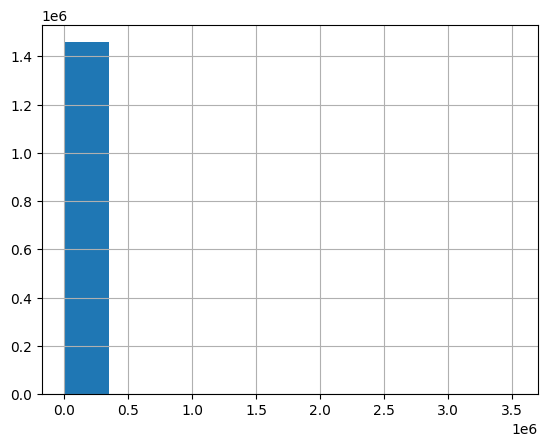

In [21]:
data.trip_duration.hist()
plt.show()